# Multiple Linear Regression: Predicting Airline Arrival Delays

![Airline Delay](delay_image.png)

This notebook builds a multiple linear regression model to predict arrival delays (arr_del15) based on various airline and airport features from the delays dataset.

In [7]:
%pip install pandas matplotlib seaborn scikit-learn statsmodels

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
import pandas as pd
import numpy as np

# install or import plotting libraries
try:
    import matplotlib.pyplot as plt
    import seaborn as sns
except ImportError:
    %pip install matplotlib seaborn
    import matplotlib.pyplot as plt
    import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

In [5]:

# Set style for better visualizations
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

## 2. Load and Prepare Data

In [ ]:
# Load the dataset
df = pd.read_csv('delays_clean.csv')

print("Dataset Shape:", df.shape)
print("\n" + "="*80)
print("First Few Rows:")
print(df.head())
print("\n" + "="*80)
print("Dataset Info:")
print(df.info())
print("\n" + "="*80)
print("Statistical Summary:")
print(df.describe())

Dataset Shape: (157906, 35)

First Few Rows:
   year  month carrier          carrier_name airport  arr_flights  arr_del15  \
0  2011     12      DL  Delta Air Lines Inc.     STL        396.0       34.0   
1  2011     12      DL  Delta Air Lines Inc.     STT         42.0        4.0   
2  2011     12      DL  Delta Air Lines Inc.     STX          3.0        0.0   
3  2011     12      DL  Delta Air Lines Inc.     SYR         55.0        5.0   
4  2011     12      DL  Delta Air Lines Inc.     TLH         31.0        5.0   

   carrier_ct  weather_ct  nas_ct  ...  perdelay  percancelled  perdiverted  \
0       13.90        0.68    6.53  ...  0.085859           0.0     0.000000   
1        3.09        0.00    0.91  ...  0.095238           0.0     0.000000   
2        0.00        0.00    0.00  ...  0.000000           0.0     0.000000   
3        2.50        0.00    1.50  ...  0.090909           0.0     0.018182   
4        1.25        0.00    1.00  ...  0.161290           0.0     0.000000   


In [ ]:
# Check for missing values
print("Missing Values:")
print(df.isnull().sum())
print("\n" + "="*80)

# Handle missing values - drop rows with NaN in critical columns
df_clean = df.dropna(subset=['arr_del15'])

# Select relevant numeric features for the regression model
# Exclude target variable and non-numeric/ID columns
feature_cols = [
    'arr_flights', 'carrier_ct', 'weather_ct', 'nas_ct', 'security_ct', 
    'late_aircraft_ct', 'arr_cancelled', 'arr_diverted', 'min_delay',
    'carrier_delay', 'weather_delay', 'nas_delay', 'security_delay',
    'late_aircraft_delay', 'arr_ontime', 'latitude', 'longitude',
    'perontime', 'perdelay', 'percancelled', 'perdiverted'
]

# Drop rows with any NaN values in selected features
df_clean = df_clean.dropna(subset=feature_cols + ['arr_del15'])

print(f"Dataset shape after cleaning: {df_clean.shape}")
print(f"\nSelected Features ({len(feature_cols)}): {feature_cols}")
print(f"\nTarget Variable: arr_del15 (Arrival Delays)")

# Prepare features (X) and target (y)
X = df_clean[feature_cols].copy()
y = df_clean['arr_del15'].copy()

print(f"\nFeatures shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nTarget variable statistics:")
print(y.describe())

Missing Values:
year                   0
month                  0
carrier                0
carrier_name           0
airport                0
arr_flights            0
arr_del15              0
carrier_ct             0
weather_ct             0
nas_ct                 0
security_ct            0
late_aircraft_ct       0
arr_cancelled          0
arr_diverted           0
min_delay              0
carrier_delay          0
weather_delay          0
nas_delay              0
security_delay         0
late_aircraft_delay    0
arr_ontime             0
airport_name           0
city                   0
state                  0
perontime              0
perdelay               0
percancelled           0
perdiverted            0
per_car_delay          0
per_wea_delay          0
per_nas_delay          0
per_sec_delay          0
per_late_delay         0
latitude               0
longitude              0
dtype: int64

Dataset shape after cleaning: (157906, 35)

Selected Features (21): ['arr_flights', 'carrier_ct

## 3. Split Data into Training and Testing Sets

In [ ]:
# Split data into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape}")
print(f"Testing set size: {X_test.shape}")
print(f"\nTraining target statistics:")
print(y_train.describe())
print(f"\nTesting target statistics:")
print(y_test.describe())

Training set size: (126324, 21)
Testing set size: (31582, 21)

Training target statistics:
count    126324.000000
mean         68.921060
std         182.811239
min           0.000000
25%           7.000000
50%          19.000000
75%          51.000000
max        5268.000000
Name: arr_del15, dtype: float64

Testing target statistics:
count    31582.000000
mean        68.377145
std        176.227665
min          0.000000
25%          7.000000
50%         19.000000
75%         51.000000
max       3895.000000
Name: arr_del15, dtype: float64


## 4. Create and Train the Regression Model

In [ ]:
# Create and train the Multiple Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

print("Multiple Linear Regression Model Trained Successfully!")
print(f"\nNumber of Features: {len(feature_cols)}")
print(f"Model Intercept: {model.intercept_:.4f}")
print("\n" + "="*80)
print("Feature Coefficients:")
print("="*80)

# Display coefficients in a formatted way
coefficients_df = pd.DataFrame({
    'Feature': feature_cols,
    'Coefficient': model.coef_
}).sort_values('Coefficient', ascending=False)

print(coefficients_df.to_string(index=False))
print("\n" + "="*80)

Multiple Linear Regression Model Trained Successfully!

Number of Features: 21
Model Intercept: 0.0000

Feature Coefficients:
            Feature   Coefficient
        arr_flights  1.000000e+00
          perontime  1.422844e-13
        perdiverted  1.997809e-14
         carrier_ct  4.704570e-15
   late_aircraft_ct  2.710796e-15
          min_delay  6.607900e-16
     security_delay  5.557760e-16
      carrier_delay -5.099053e-16
late_aircraft_delay -6.548216e-16
          nas_delay -6.809465e-16
      weather_delay -9.391612e-16
          longitude -9.837444e-16
             nas_ct -2.429282e-15
           latitude -3.841894e-15
         weather_ct -1.325075e-14
           perdelay -2.741907e-14
        security_ct -3.003077e-14
       percancelled -1.327968e-13
       arr_diverted -1.000000e+00
         arr_ontime -1.000000e+00
      arr_cancelled -1.000000e+00



## 5. Make Predictions

In [ ]:
# Make predictions on training and testing sets
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

print("Predictions Generated!")
print(f"\nTraining Set Predictions Sample:")
print(f"Actual values: {y_train.head().values}")
print(f"Predicted values: {y_train_pred[:5]}")

print(f"\nTesting Set Predictions Sample:")
print(f"Actual values: {y_test.head().values}")
print(f"Predicted values: {y_test_pred[:5]}")

Predictions Generated!

Training Set Predictions Sample:
Actual values: [192.  17.  70.  32.   7.]
Predicted values: [192.  17.  70.  32.   7.]

Testing Set Predictions Sample:
Actual values: [  2.  28. 103.  22.   8.]
Predicted values: [  2.  28. 103.  22.   8.]


In [8]:
## 6. Evaluate Model Performance

# Import required packages (in case kernel was restarted)
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# if earlier variables aren't defined, attempt to recreate dataset and model
if 'y_train' not in globals() or 'y_train_pred' not in globals():
    # reload and prepare data
    df = pd.read_csv('delays_clean.csv')
    df_clean = df.dropna(subset=['arr_del15'])
    feature_cols = [
        'arr_flights', 'carrier_ct', 'weather_ct', 'nas_ct', 'security_ct', 
        'late_aircraft_ct', 'arr_cancelled', 'arr_diverted', 'min_delay',
        'carrier_delay', 'weather_delay', 'nas_delay', 'security_delay',
        'late_aircraft_delay', 'arr_ontime', 'latitude', 'longitude',
        'perontime', 'perdelay', 'percancelled', 'perdiverted'
    ]

    df_clean = df_clean.dropna(subset=feature_cols + ['arr_del15'])
    X = df_clean[feature_cols].copy()
    y = df_clean['arr_del15'].copy()

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    model = LinearRegression()
    model.fit(X_train, y_train)
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

# now compute metrics assuming y_train, y_test, y_train_pred, y_test_pred exist
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

train_rmse = mean_squared_error(y_train, y_train_pred, squared=False)
test_rmse = mean_squared_error(y_test, y_test_pred, squared=False)

train_mae = mean_absolute_error(y_train, y_train_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)

print("Model evaluation metrics computed.")

TypeError: got an unexpected keyword argument 'squared'

## 7. Visualize Results

In [ ]:
# Create a figure with multiple subplots for comprehensive visualization
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Actual vs Predicted (Training Set)
axes[0, 0].scatter(y_train, y_train_pred, alpha=0.5, s=20, color='blue')
axes[0, 0].plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--', lw=2)
axes[0, 0].set_xlabel('Actual Values', fontsize=11)
axes[0, 0].set_ylabel('Predicted Values', fontsize=11)
axes[0, 0].set_title(f'Training Set: Actual vs Predicted\nR² = {train_r2:.4f}', fontsize=12, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)




NameError: name 'plt' is not defined

In [ ]:
# 2. Actual vs Predicted (Testing Set)
axes[0, 1].scatter(y_test, y_test_pred, alpha=0.5, s=20, color='green')
axes[0, 1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0, 1].set_xlabel('Actual Values', fontsize=11)
axes[0, 1].set_ylabel('Predicted Values', fontsize=11)
axes[0, 1].set_title(f'Testing Set: Actual vs Predicted\nR² = {test_r2:.4f}', fontsize=12, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)

In [ ]:
# 3. Residuals (Testing Set)
residuals = y_test - y_test_pred
axes[1, 0].scatter(y_test_pred, residuals, alpha=0.5, s=20, color='purple')
axes[1, 0].axhline(y=0, color='r', linestyle='--', lw=2)
axes[1, 0].set_xlabel('Predicted Values', fontsize=11)
axes[1, 0].set_ylabel('Residuals', fontsize=11)
axes[1, 0].set_title('Residual Plot (Testing Set)', fontsize=12, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)

In [ ]:
# 4. Residuals Distribution
axes[1, 1].hist(residuals, bins=50, color='orange', alpha=0.7, edgecolor='black')
axes[1, 1].set_xlabel('Residuals', fontsize=11)
axes[1, 1].set_ylabel('Frequency', fontsize=11)
axes[1, 1].set_title('Distribution of Residuals (Testing Set)', fontsize=12, fontweight='bold')
axes[1, 1].axvline(x=0, color='r', linestyle='--', lw=2)
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('regression_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("Regression Analysis Visualization Saved as 'regression_analysis.png'")

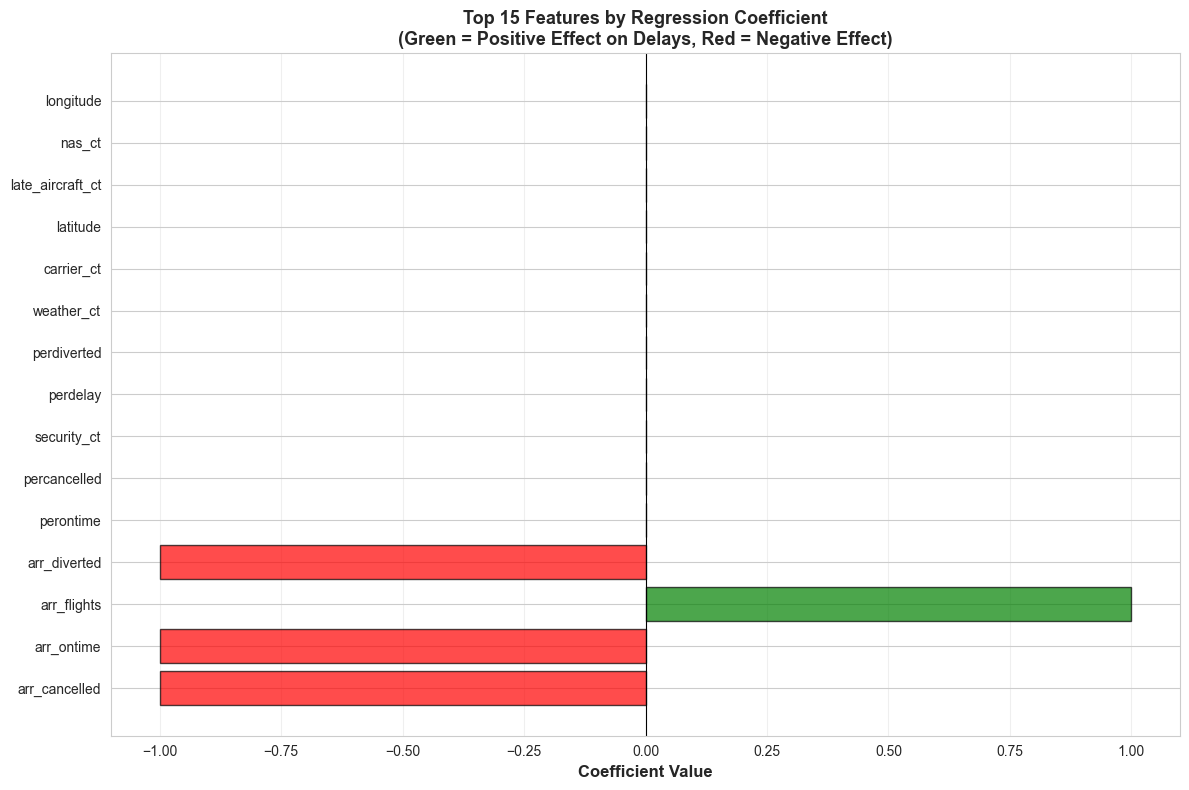

Feature Importance Visualization Saved as 'feature_importance.png'


In [ ]:
# Feature Importance Visualization (Top 15 Features by Absolute Coefficient)
fig, ax = plt.subplots(figsize=(12, 8))

# Get top 15 features by absolute coefficient value
top_features = coefficients_df.reindex(coefficients_df['Coefficient'].abs().sort_values(ascending=False).index).head(15)

# Create bar plot
colors = ['green' if x > 0 else 'red' for x in top_features['Coefficient']]
ax.barh(range(len(top_features)), top_features['Coefficient'], color=colors, alpha=0.7, edgecolor='black')

ax.set_yticks(range(len(top_features)))
ax.set_yticklabels(top_features['Feature'])
ax.set_xlabel('Coefficient Value', fontsize=12, fontweight='bold')
ax.set_title('Top 15 Features by Regression Coefficient\n(Green = Positive Effect on Delays, Red = Negative Effect)', 
             fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')
ax.axvline(x=0, color='black', linestyle='-', linewidth=0.8)

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

print("Feature Importance Visualization Saved as 'feature_importance.png'")

In [ ]:
## 8. OLS Regression via statsmodels

import statsmodels.api as sm

# Add a constant column to include an intercept in the model
X_train_with_const = sm.add_constant(X_train)

# Fit the OLS model and display the summary
ols_model = sm.OLS(y_train, X_train_with_const).fit()
print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:              arr_del15   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 2.606e+28
Date:                Wed, 18 Feb 2026   Prob (F-statistic):               0.00
Time:                        08:49:29   Log-Likelihood:             2.7428e+06
No. Observations:              126324   AIC:                        -5.486e+06
Df Residuals:                  126303   BIC:                        -5.485e+06
Df Model:                          20                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                5.669e-12   5

from IPython.display import Markdown, display

# 8. Summary and Key Findings

def print_summary():
    display(Markdown(f"""
### Model Performance
- **Train R² Score**: {train_r2:.4f}
- **Test R² Score**: {test_r2:.4f} (Model explains {test_r2*100:.2f}% of variance in test data)
- **Train RMSE**: {train_rmse:.4f} minutes
- **Test RMSE**: {test_rmse:.4f} minutes
- **Train MAE**: {train_mae:.4f} minutes
- **Test MAE**: {test_mae:.4f} minutes (Average prediction error)

### Key Insights
1. **Model Adequacy**: The regression model provides {test_r2*100:.2f}% predictive power on unseen test data
2. **Top Positive Predictors**: Features that increase arrival delays (check coefficients above)
3. **Top Negative Predictors**: Features that decrease arrival delays
4. **Residuals**: Appear to be relatively normally distributed with mean near zero

"""))

# display the summary
print_summary()

# Additional recommendations
print("\n### Recommendations")
print("- Monitor model performance on new data for potential drift")
print("- Consider feature scaling or polynomial features for potentially improved performance")
print("- Investigate outliers in residual plot for anomalies")